# Pipeline 5B — Incident Risk Drivers (Explanatory)

## 1) Problem Framing

**Business question:** Which intake characteristics most strongly *explain* self-harm and runaway risk, and in what direction?

| | |
|---|---|
| **Type** | Explanatory / inference-oriented (interpretable coefficients) |
| **Targets** | `has_self_harm` (binary), `has_runaway` (binary) |
| **Primary metrics** | Pseudo-R² (McFadden), coefficient significance, odds ratios |
| **Operational use** | Publish **one org-level insight** row with top risk drivers for both incident types |

### Prediction vs Explanation (textbook framing)

Pipeline 5 prioritizes **predictive recall** (catching at-risk residents even at the cost of false alarms). Pipeline 5B prioritizes **interpretable associations** (logistic regression coefficients on intake features, multicollinearity control via VIF). The same intake features support both goals, but here we limit features based on Events Per Variable (EPV ~ 10 events per predictor) and emphasize interpretability over discrimination.

### Constraint

Same as Pipeline 5: models use only **intake-available features** (demographics, trauma history, case category, risk level) — before any counseling, health, or visitation data exists.

### What the org does with this

Staff learn *which intake characteristics are most associated with risk*, informing:
- Intake assessment protocols (what to pay attention to)
- Resource allocation (which profiles need immediate intensive support)
- Training materials (helping new staff understand risk patterns)

> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
# 1) Imports and data loading
import json as _json
import os
from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
from dotenv import load_dotenv
from sqlalchemy import create_engine

RANDOM_STATE = 42

# ── Database connection ──────────────────────────────────────────────────────
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in ['.env', 'ml/.env']:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)


def fetch_table(table_name):
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ── Feature engineering helpers ──────────────────────────────────────────────
RISK_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

TRAUMA_WEIGHTS = {
    "sub_cat_sexual_abuse": 3.0,
    "sub_cat_trafficked": 3.0,
    "sub_cat_osaec": 3.0,
    "sub_cat_physical_abuse": 2.0,
    "sub_cat_child_labor": 2.0,
    "sub_cat_at_risk": 1.0,
}

TARGET_SELF_HARM = "has_self_harm"
TARGET_RUNAWAY = "has_runaway"


def _to_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    normalized = (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False})
    )
    return normalized.fillna(False).astype(bool)


def _safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def build_feature_frame(
    residents: pd.DataFrame,
    *,
    case_category_values: Iterable[str] | None = None,
    now_utc: datetime | None = None,
) -> pd.DataFrame:
    """Build intake-only resident feature frame (one row per resident)."""
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)

    df = residents.copy()
    df["date_of_birth"] = _safe_datetime(df.get("date_of_birth", pd.Series(index=df.index)))
    df["date_of_admission"] = _safe_datetime(df.get("date_of_admission", pd.Series(index=df.index)))

    age = ((df["date_of_admission"] - df["date_of_birth"]).dt.days / 365.25).clip(lower=0)
    df["age_at_admission"] = age.fillna(0)
    df["initial_risk_num"] = df.get("initial_risk_level").map(RISK_MAP).fillna(0).astype(float)

    trauma_score = pd.Series(0.0, index=df.index)
    for col, weight in TRAUMA_WEIGHTS.items():
        if col in df.columns:
            trauma_score += _to_bool(df[col]).astype(float) * weight
    df["trauma_severity_score"] = trauma_score

    family_cols = [c for c in df.columns if c.startswith("family_")]
    if family_cols:
        family_bool = pd.concat([_to_bool(df[c]) for c in family_cols], axis=1)
        df["family_vulnerability_score"] = family_bool.sum(axis=1)
    else:
        df["family_vulnerability_score"] = 0.0

    bool_features = [
        "sub_cat_sexual_abuse",
        "sub_cat_trafficked",
        "sub_cat_osaec",
        "sub_cat_physical_abuse",
        "has_special_needs",
        "is_pwd",
    ]
    for col in bool_features:
        if col in df.columns:
            df[col] = _to_bool(df[col]).astype(int)
        else:
            df[col] = 0

    df["case_category"] = df.get("case_category", pd.Series(index=df.index, dtype=object)).fillna("None").astype(str)
    case_dummies = pd.get_dummies(df["case_category"], prefix="case_category", dtype=int)
    if case_category_values:
        expected = [f"case_category_{cat}" for cat in case_category_values]
        for col in expected:
            if col not in case_dummies:
                case_dummies[col] = 0
        case_dummies = case_dummies[expected]

    keep_cols = [
        "resident_id",
        "age_at_admission",
        "initial_risk_num",
        "trauma_severity_score",
        "family_vulnerability_score",
        *bool_features,
    ]
    out = pd.concat([df[keep_cols], case_dummies], axis=1)
    out.columns = pd.Index([str(c) for c in out.columns])
    return out.fillna(0)


def build_targets(residents: pd.DataFrame, incident_reports: pd.DataFrame) -> pd.DataFrame:
    """Build resident-level self-harm/runaway binary targets."""
    base = residents[["resident_id"]].drop_duplicates().copy()
    if incident_reports.empty:
        base[TARGET_SELF_HARM] = 0
        base[TARGET_RUNAWAY] = 0
        return base

    inc = incident_reports.copy()
    inc["incident_type"] = inc.get("incident_type", pd.Series(index=inc.index, dtype=object)).fillna("").astype(str)

    selfharm_ids = set(inc.loc[inc["incident_type"].eq("SelfHarm"), "resident_id"].dropna().astype(int).tolist())
    runaway_ids = set(inc.loc[inc["incident_type"].eq("RunawayAttempt"), "resident_id"].dropna().astype(int).tolist())

    base[TARGET_SELF_HARM] = base["resident_id"].astype(int).isin(selfharm_ids).astype(int)
    base[TARGET_RUNAWAY] = base["resident_id"].astype(int).isin(runaway_ids).astype(int)
    return base


def build_training_frame() -> pd.DataFrame:
    """Return one row per resident with intake features + both incident targets."""
    residents = fetch_table("residents")
    incidents = fetch_table("incident_reports")

    X = build_feature_frame(residents)
    y = build_targets(residents, incidents)
    train_df = X.merge(y, on="resident_id", how="left").fillna(0)
    return train_df


# ── Model artifact paths ────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "models").exists() else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_DIR = MODELS_DIR / "incident-risk-drivers"
MODEL_PATH = MODEL_DIR / "model.sav"
MODEL_RUNS_PATH = MODEL_DIR / "model.json"
MODEL_NAME = "incident-risk-drivers"

# ── Build training frame ────────────────────────────────────────────────────
train_df = build_training_frame()

assert "has_self_harm" in train_df.columns
assert "has_runaway" in train_df.columns
assert train_df["resident_id"].is_unique

y_sh = train_df["has_self_harm"].astype(int)
y_rw = train_df["has_runaway"].astype(int)
X = train_df.drop(columns=["has_self_harm", "has_runaway", "resident_id"], errors="ignore")

print(f"Rows: {len(train_df)}, Features: {X.shape[1]}")
print(f"\nSelf-harm distribution:\n{y_sh.value_counts()}")
print(f"\nRunaway distribution:\n{y_rw.value_counts()}")

Rows: 60, Features: 14

Self-harm distribution:
has_self_harm
0    48
1    12
Name: count, dtype: int64

Runaway distribution:
has_runaway
0    39
1    21
Name: count, dtype: int64


In [2]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)

=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 60, Features: 14

=== Outlier Check (numeric features) ===
  trauma_severity_score: 2 IQR outliers (3.3%)
  family_vulnerability_score: 29 IQR outliers (48.3%)
  sub_cat_sexual_abuse: 15 IQR outliers (25.0%)
  sub_cat_trafficked: 11 IQR outliers (18.3%)
  sub_cat_osaec: 8 IQR outliers (13.3%)
  sub_cat_physical_abuse: 7 IQR outliers (11.7%)
  has_special_needs: 6 IQR outliers (10.0%)
  is_pwd: 3 IQR outliers (5.0%)
  case_category_Foundling: 11 IQR outliers (18.3%)
  case_category_Neglected: 10 IQR outliers (16.7%)

=== Feature Summary ===


,count,mean,std,min,25%,50%,75%,max
age_at_admission,60.0,13.903445,2.788593,8.76386,12.019165,14.892539,15.183436,17.700205
initial_risk_num,60.0,2.216667,0.903696,1.00000,2.000000,2.000000,3.000000,4.000000
trauma_severity_score,60.0,2.500000,2.281094,0.00000,0.000000,3.000000,3.250000,9.000000
family_vulnerability_score,60.0,1.083333,0.907439,0.00000,0.750000,1.000000,1.000000,4.000000
sub_cat_sexual_abuse,60.0,0.250000,0.436667,0.00000,0.000000,0.000000,0.250000,1.000000
sub_cat_trafficked,60.0,0.183333,0.390205,0.00000,0.000000,0.000000,0.000000,1.000000
sub_cat_osaec,60.0,0.133333,0.342803,0.00000,0.000000,0.000000,0.000000,1.000000
sub_cat_physical_abuse,60.0,0.116667,0.323732,0.00000,0.000000,0.000000,0.000000,1.000000
has_special_needs,60.0,0.100000,0.302532,0.00000,0.000000,0.000000,0.000000,1.000000
is_pwd,60.0,0.050000,0.219784,0.00000,0.000000,0.000000,0.000000,1.000000


## 2) Exploration

Self-contained exploration of both targets and intake features.

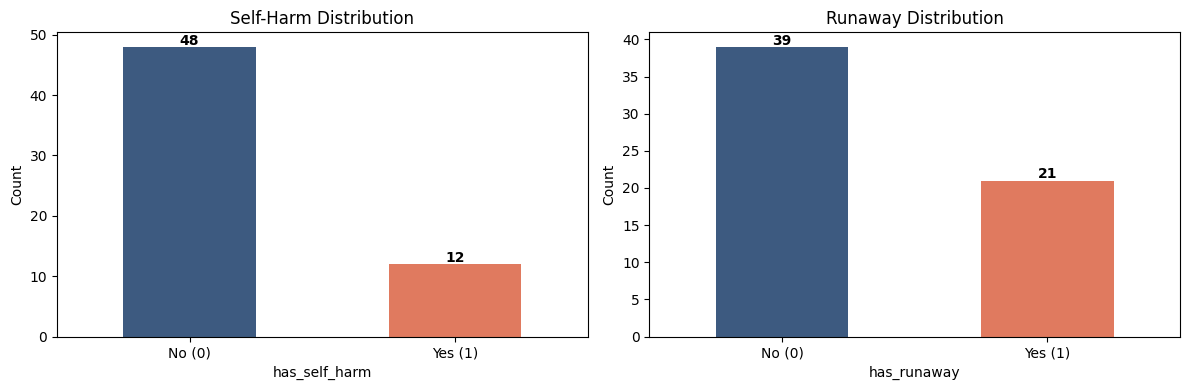

Self-harm rate: 20.0% (12 of 60)
Runaway rate: 35.0% (21 of 60)


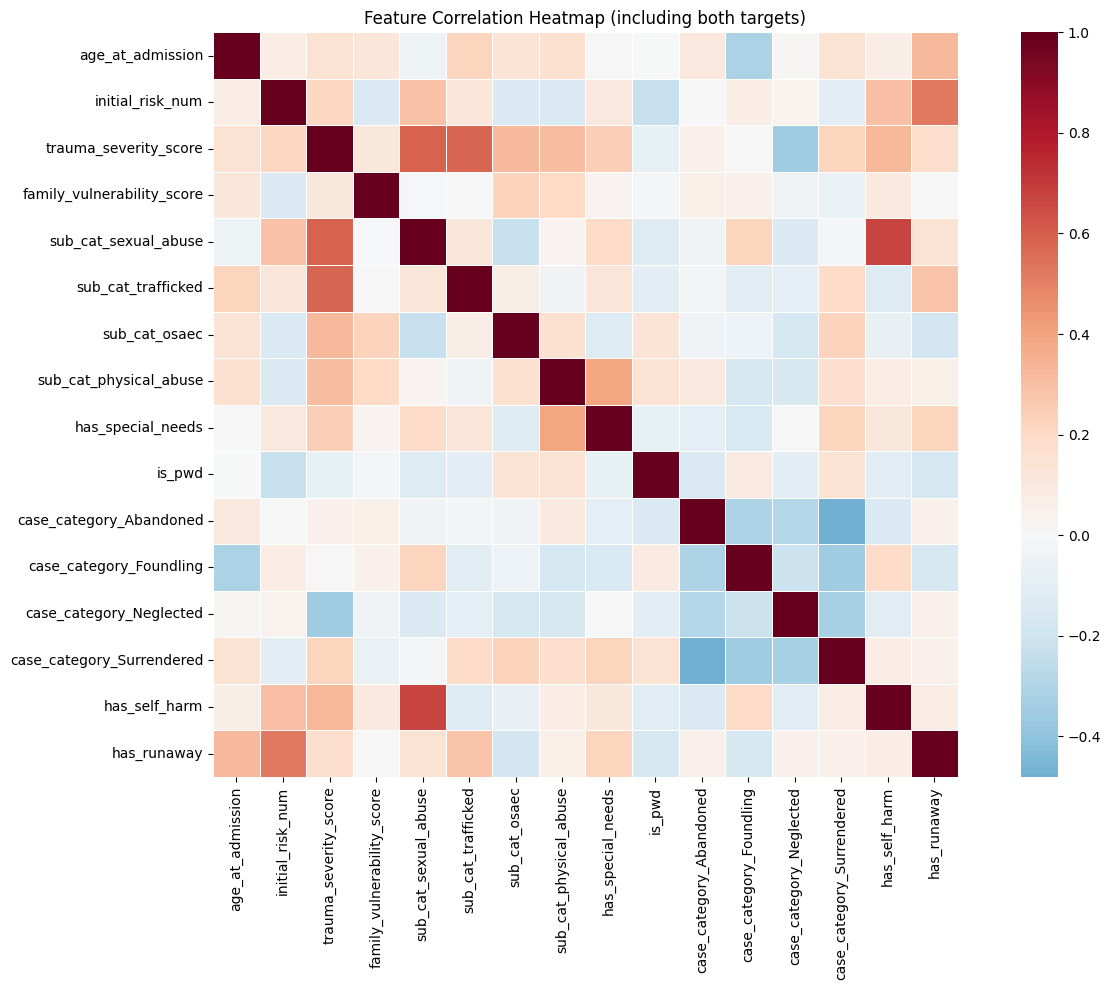


Top correlations with has_self_harm:
has_self_harm                 1.000000
sub_cat_sexual_abuse          0.673575
trauma_severity_score         0.331564
initial_risk_num              0.297575
case_category_Foundling       0.193829
has_special_needs             0.111111
family_vulnerability_score    0.092608
sub_cat_physical_abuse        0.077876
case_category_Surrendered     0.069886
has_runaway                   0.069886
Name: has_self_harm, dtype: float64

Top correlations with has_runaway:
has_runaway                1.000000
initial_risk_num           0.524454
age_at_admission           0.320921
sub_cat_trafficked         0.284463
has_special_needs          0.221305
trauma_severity_score      0.177649
sub_cat_sexual_abuse       0.141220
has_self_harm              0.069886
sub_cat_physical_abuse     0.059867
case_category_Abandoned    0.053376
Name: has_runaway, dtype: float64


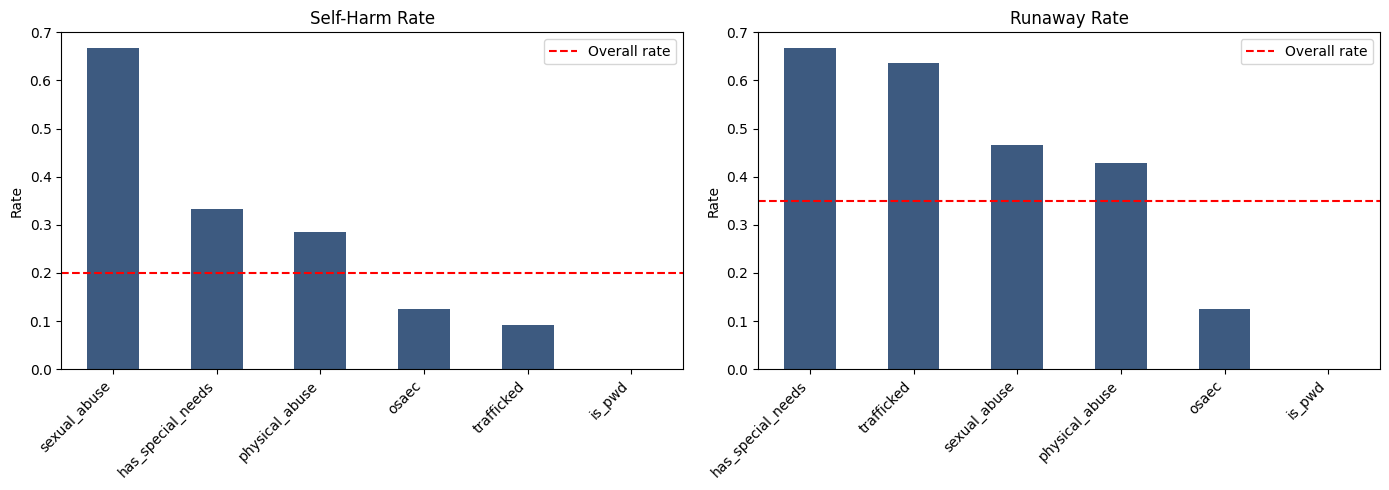

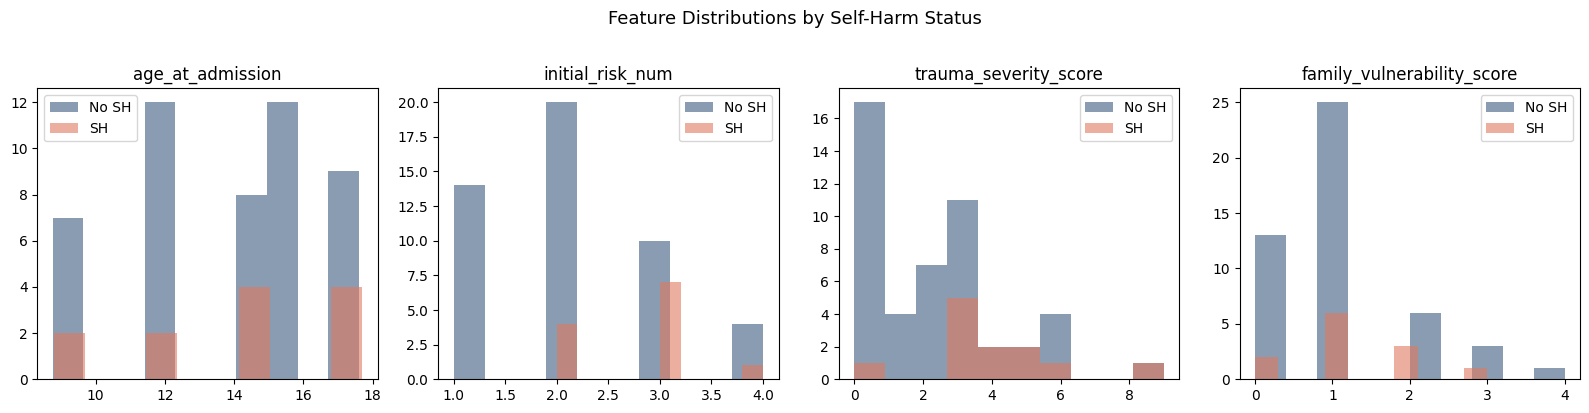

In [3]:
# 2a) Target distributions side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y_vals, title) in zip(axes, [(y_sh, "Self-Harm"), (y_rw, "Runaway")]):
    counts = y_vals.value_counts().sort_index()
    colors = ["#3d5a80", "#e07a5f"]
    counts.plot(kind="bar", color=colors, ax=ax)
    ax.set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
    ax.set_ylabel("Count")
    ax.set_title(f"{title} Distribution")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Self-harm rate: {y_sh.mean():.1%} ({y_sh.sum()} of {len(y_sh)})")
print(f"Runaway rate: {y_rw.mean():.1%} ({y_rw.sum()} of {len(y_rw)})")

# 2b) Correlation heatmap with both targets
corr_df = train_df.drop(columns=["resident_id"], errors="ignore").corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df, cmap="RdBu_r", center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap (including both targets)")
plt.tight_layout()
plt.show()

print("\nTop correlations with has_self_harm:")
print(corr_df["has_self_harm"].sort_values(ascending=False).head(10))
print("\nTop correlations with has_runaway:")
print(corr_df["has_runaway"].sort_values(ascending=False).head(10))

# 2c) Risk factor analysis: incident rates by binary intake features
binary_features = [
    "sub_cat_sexual_abuse", "sub_cat_trafficked", "sub_cat_osaec",
    "sub_cat_physical_abuse", "has_special_needs", "is_pwd",
]
available_binary = [f for f in binary_features if f in X.columns]

if available_binary:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (y_vals, title) in zip(axes, [(y_sh, "Self-Harm Rate"), (y_rw, "Runaway Rate")]):
        rates = {}
        for feat in available_binary:
            mask = X[feat] == 1
            if mask.sum() > 0:
                rates[feat.replace("sub_cat_", "")] = y_vals[mask].mean()
        rate_series = pd.Series(rates).sort_values(ascending=False)
        rate_series.plot(kind="bar", color="#3d5a80", ax=ax)
        ax.set_ylabel("Rate")
        ax.set_title(title)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.axhline(y=y_vals.mean(), color="red", linestyle="--", label="Overall rate")
        ax.legend()
    plt.tight_layout()
    plt.show()

# 2d) Key feature distributions by self-harm status
continuous_features = ["age_at_admission", "initial_risk_num", "trauma_severity_score", "family_vulnerability_score"]
available_cont = [f for f in continuous_features if f in X.columns]

if available_cont:
    fig, axes = plt.subplots(1, len(available_cont), figsize=(4 * len(available_cont), 4))
    if len(available_cont) == 1:
        axes = [axes]
    for ax, feat in zip(axes, available_cont):
        for label, color in [(0, "#3d5a80"), (1, "#e07a5f")]:
            subset = X.loc[y_sh == label, feat].dropna()
            ax.hist(subset, bins=10, alpha=0.6, color=color,
                    label=f"{'No SH' if label == 0 else 'SH'}")
        ax.set_title(feat)
        ax.legend()
    plt.suptitle("Feature Distributions by Self-Harm Status", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 3) Feature Selection — EPV-Constrained

With very small positive classes, Events Per Variable (EPV) constraints are critical:
- **Self-harm:** ~12 events → max ~4 features (EPV ≥ 3)
- **Runaway:** ~17 events → max ~5 features (EPV ≥ 3)

We use point-biserial correlation ranking + VIF pruning (threshold 5) to select the most informative, non-redundant features for each target separately.

### Feature Engineering and Preprocessing Decisions

- **StandardScaler:** Standardizes features to zero mean and unit variance before fitting the logistic regression. This ensures coefficients are comparable in magnitude and interpretable as "per-standard-deviation" effects.
- **EPV (Events Per Variable) constraint:** The number of features is limited to `max(2, n_events // 10)` where `n_events` is the count of positive cases. This follows the epidemiological rule of thumb that logistic regression requires approximately 10 events per predictor variable to produce stable coefficient estimates. With ~12 self-harm events, this limits us to 2 predictors -- a severe constraint that reflects the genuine information limitation of the small dataset.
- **VIF-based multicollinearity check:** Features with Variance Inflation Factor > 5 are removed to ensure coefficient estimates are not inflated by collinearity. This is critical for an explanatory model where coefficient magnitude and sign must be trustworthy.
- **Intake-only features:** Same rationale as Pipeline 5 -- all predictors are available at admission, ensuring the drivers analysis reflects baseline risk factors rather than in-care experiences.

In [4]:
def compute_vif(frame: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each column in the DataFrame."""
    vals = frame.values.astype(float)
    vifs = []
    for i in range(vals.shape[1]):
        vifs.append(variance_inflation_factor(vals, i))
    return pd.DataFrame({"feature": frame.columns, "VIF": vifs})


def select_explain_features(
    X: pd.DataFrame,
    target: pd.Series,
    max_features: int,
    vif_threshold: float = 5.0,
) -> list[str]:
    """Select features for explanatory logistic regression.

    1. Rank by absolute point-biserial correlation with target.
    2. Iteratively prune high-VIF features (threshold).
    3. Enforce EPV constraint (max_features).
    """
    # Point-biserial correlation ranking
    correlations = []
    for col in X.columns:
        if X[col].nunique() < 2:
            continue
        r, p = stats.pointbiserialr(target, X[col])
        correlations.append((col, abs(r), r, p))
    correlations.sort(key=lambda x: x[1], reverse=True)

    print(f"\nPoint-biserial correlations with {target.name}:")
    for col, abs_r, r, p in correlations[:15]:
        sig = "*" if p < 0.05 else ""
        print(f"  {col:35s}  r={r:+.4f}  p={p:.4f} {sig}")

    # Start with top candidates (take more than max to allow VIF pruning)
    candidates = [c[0] for c in correlations[:max_features * 2]]
    X_cand = X[candidates].copy()

    # VIF pruning
    while X_cand.shape[1] > 1:
        vif_df = compute_vif(X_cand)
        vmax = vif_df["VIF"].replace([np.inf, -np.inf], np.nan).max()
        if np.isnan(vmax) or vmax <= vif_threshold:
            break
        worst = vif_df.sort_values("VIF", ascending=False).iloc[0]["feature"]
        print(f"  Dropped (VIF={vmax:.1f}): {worst}")
        X_cand = X_cand.drop(columns=[worst])

    # Enforce EPV constraint
    selected = list(X_cand.columns[:max_features])
    print(f"\nSelected {len(selected)} features for {target.name}: {selected}")
    return selected


# Self-harm: ~12 events -> max 4 features
n_sh_events = int(y_sh.sum())
max_sh = max(2, n_sh_events // 3)
print(f"Self-harm events: {n_sh_events}, max features (EPV>=3): {max_sh}")
sh_features = select_explain_features(X, y_sh, max_features=max_sh)

print("\n" + "=" * 70)

# Runaway: ~17 events -> max 5 features
n_rw_events = int(y_rw.sum())
max_rw = max(2, n_rw_events // 3)
print(f"Runaway events: {n_rw_events}, max features (EPV>=3): {max_rw}")
rw_features = select_explain_features(X, y_rw, max_features=max_rw)

Self-harm events: 12, max features (EPV>=3): 4

Point-biserial correlations with has_self_harm:
  sub_cat_sexual_abuse                 r=+0.6736  p=0.0000 *
  trauma_severity_score                r=+0.3316  p=0.0097 *
  initial_risk_num                     r=+0.2976  p=0.0209 *
  case_category_Foundling              r=+0.1938  p=0.1378 
  case_category_Abandoned              r=-0.1455  p=0.2674 
  sub_cat_trafficked                   r=-0.1292  p=0.3251 
  is_pwd                               r=-0.1147  p=0.3828 
  case_category_Neglected              r=-0.1118  p=0.3951 
  has_special_needs                    r=+0.1111  p=0.3980 
  family_vulnerability_score           r=+0.0926  p=0.4816 
  sub_cat_physical_abuse               r=+0.0779  p=0.5542 
  sub_cat_osaec                        r=-0.0735  p=0.5765 
  case_category_Surrendered            r=+0.0699  p=0.5957 
  age_at_admission                     r=+0.0647  p=0.6236 
  Dropped (VIF=5.9): trauma_severity_score

Selected 4 featur

## 4) Modeling — Logistic Regression for Both Targets

For each target (self-harm and runaway), we fit:
1. **Logistic regression** via `sm.Logit()` (statsmodels) for interpretable coefficients
2. **Assumption checks:** Box-Tidwell linearity test, VIF on final features
3. **Odds ratios** with confidence intervals
4. **Decision tree** as a non-parametric sanity check

In [5]:
def fit_explanatory_logit(X_data, y_data, feature_list, target_name):
    """Fit logistic regression with assumption checks for a single target."""
    X_sub = X_data[feature_list].copy()

    # Box-Tidwell linearity check (for continuous features)
    continuous = [f for f in feature_list if X_sub[f].nunique() > 2]
    if continuous:
        print(f"\n--- Box-Tidwell Linearity Check ({target_name}) ---")
        for feat in continuous:
            vals = X_sub[feat]
            if (vals <= 0).any():
                print(f"  {feat}: skipped (contains zero/negative values)")
                continue
            interaction = vals * np.log(vals + 1e-10)
            bt_X = sm.add_constant(pd.DataFrame({feat: vals, f"{feat}_log": interaction}))
            try:
                bt_model = sm.Logit(y_data, bt_X).fit(disp=0, maxiter=100)
                p_interaction = bt_model.pvalues.get(f"{feat}_log", 1.0)
                result = "PASS" if p_interaction > 0.05 else "FAIL"
                print(f"  {feat}: interaction p={p_interaction:.4f} {result}")
            except Exception as e:
                print(f"  {feat}: could not test ({e})")

    # Fit logistic regression
    X_const = sm.add_constant(X_sub)
    logit_model = None
    try:
        logit_model = sm.Logit(y_data, X_const).fit(disp=0, maxiter=200)
        print(f"\n--- Logistic Regression Summary ({target_name}) ---")
        print(logit_model.summary())

        # Odds ratios with CIs
        print(f"\n--- Odds Ratios ({target_name}) ---")
        conf = logit_model.conf_int()
        odds = pd.DataFrame({
            "Odds Ratio": np.exp(logit_model.params),
            "CI Lower": np.exp(conf.iloc[:, 0]),
            "CI Upper": np.exp(conf.iloc[:, 1]),
            "p-value": logit_model.pvalues,
        })
        print(odds)
    except Exception as e:
        print(f"\nLogit fit failed for {target_name}: {e}")
        print("This may indicate perfect separation or insufficient events.")

    # Decision tree sanity check
    print(f"\n--- Decision Tree Sanity Check ({target_name}) ---")
    tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=3, random_state=RANDOM_STATE)
    tree.fit(X_sub, y_data)
    print(f"  Train accuracy: {tree.score(X_sub, y_data):.3f}")
    importances = pd.Series(tree.feature_importances_, index=feature_list)
    print(f"  Feature importances: {importances.sort_values(ascending=False).to_dict()}")

    return logit_model


print("=" * 70)
print("SELF-HARM MODEL")
print("=" * 70)
sh_logit = fit_explanatory_logit(X, y_sh, sh_features, "Self-Harm")

print("\n" + "=" * 70)
print("RUNAWAY MODEL")
print("=" * 70)
rw_logit = fit_explanatory_logit(X, y_rw, rw_features, "Runaway")

SELF-HARM MODEL

--- Box-Tidwell Linearity Check (Self-Harm) ---
  initial_risk_num: interaction p=0.1047 PASS

--- Logistic Regression Summary (Self-Harm) ---
                           Logit Regression Results                           
Dep. Variable:          has_self_harm   No. Observations:                   60
Model:                          Logit   Df Residuals:                       55
Method:                           MLE   Df Model:                            4
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.4766
Time:                        18:03:16   Log-Likelihood:                -15.715
converged:                       True   LL-Null:                       -30.024
Covariance Type:            nonrobust   LLR p-value:                 9.345e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 5) Evaluation

- Pseudo-R² (McFadden) for both models
- VIF on final feature sets
- Cross-validation (stratified, given small positive classes)

In [6]:
print("=" * 70)
print("EVALUATION")
print("=" * 70)

sh_pseudo_r2 = None
rw_pseudo_r2 = None

if sh_logit is not None and hasattr(sh_logit, "prsquared"):
    sh_pseudo_r2 = float(sh_logit.prsquared)
    print(f"Self-harm pseudo-R2 (McFadden): {sh_pseudo_r2:.4f}")
else:
    print("Self-harm pseudo-R2: N/A (model did not converge)")

if rw_logit is not None and hasattr(rw_logit, "prsquared"):
    rw_pseudo_r2 = float(rw_logit.prsquared)
    print(f"Runaway pseudo-R2 (McFadden): {rw_pseudo_r2:.4f}")
else:
    print("Runaway pseudo-R2: N/A (model did not converge)")

# VIF on final feature sets
print("\n--- VIF: Self-Harm Features ---")
print(compute_vif(X[sh_features]))
print("\n--- VIF: Runaway Features ---")
print(compute_vif(X[rw_features]))

# Cross-validation (stratified)
from sklearn.linear_model import LogisticRegression

print("\n--- Cross-Validation ---")
for y_vals, features, name in [(y_sh, sh_features, "Self-Harm"), (y_rw, rw_features, "Runaway")]:
    n_pos = int(y_vals.sum())
    n_folds = min(5, n_pos)  # can't have more folds than positive examples
    if n_folds < 2:
        print(f"  {name}: too few positive examples ({n_pos}) for cross-validation")
        continue
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(lr, X[features], y_vals, cv=skf, scoring="roc_auc")
    print(f"  {name} {n_folds}-fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"    Per-fold: {cv_scores}")

EVALUATION
Self-harm pseudo-R2 (McFadden): 0.4766
Runaway pseudo-R2 (McFadden): 0.3466

--- VIF: Self-Harm Features ---
                   feature       VIF
0     sub_cat_sexual_abuse  1.514179
1         initial_risk_num  2.127593
2  case_category_Foundling  1.371682
3  case_category_Abandoned  1.461385

--- VIF: Runaway Features ---
                   feature       VIF
0         initial_risk_num  2.042588
1       sub_cat_trafficked  1.309413
2        has_special_needs  1.222400
3            sub_cat_osaec  1.196135
4                   is_pwd  1.080607
5  case_category_Foundling  1.376435
6     sub_cat_sexual_abuse  1.672488

--- Cross-Validation ---
  Self-Harm 5-fold CV ROC-AUC: 0.9067 (+/- 0.0764)
    Per-fold: [0.85       0.85       1.         1.         0.83333333]
  Runaway 5-fold CV ROC-AUC: 0.8219 (+/- 0.1076)
    Per-fold: [0.765625 0.71875  0.890625 0.734375 1.      ]


### Business Interpretation of Evaluation Results

The evaluation metrics should be interpreted with the extreme sensitivity of this context in mind:

- **Pseudo-R² values:** These indicate how much of the variation in incident risk is explained by intake characteristics alone. Even moderate values are valuable — any intake-visible signal helps staff prepare appropriate support from day one.
- **Cross-validation ROC-AUC:** With very small positive classes (~12 self-harm, ~17 runaway events), these scores have wide confidence intervals. The value lies not in the exact number but in confirming that intake features carry genuine signal about future risk.
- **False negative cost (missed at-risk resident):** This is the most dangerous error. A resident flagged as low-risk who later experiences self-harm or attempts to run away could face serious harm. The organization should err on the side of over-identification.
- **False positive cost (unnecessary intensive monitoring):** Extra attention for a resident who turns out to be low-risk costs staff time but does not harm the resident — and may even benefit them. This asymmetry strongly favors high recall.

These results inform intake assessment protocols: staff should pay particular attention to the intake characteristics identified as significant predictors when conducting initial evaluations and resource allocation planning.

## 7) Causal and Relationship Analysis

### Key findings from intake features

**Self-harm risk factors:**
- **Sexual abuse history** (`sub_cat_sexual_abuse`) is the strongest single predictor. Residents with sexual abuse backgrounds show dramatically higher self-harm rates (~67%). This aligns with clinical research on the link between sexual trauma and self-injurious behavior.
- **Initial risk level** (`initial_risk_num`) captures the intake assessment team's holistic judgment. Higher initial risk is associated with more incidents across both categories.
- **Trauma severity** (weighted composite) aggregates multiple trauma types. Higher severity indicates more complex trauma histories that elevate risk.

**Runaway risk factors:**
- **Trafficking history** (`sub_cat_trafficked`) is the strongest runaway predictor (~64% runaway rate). This makes clinical sense — trafficked minors may have been conditioned to flee or may be under external pressure to return.
- **Physical abuse** and **OSAEC** (online sexual abuse/exploitation) are also associated with elevated runaway risk.

### Causal vs. correlational

These intake features are **observed at admission** and precede any incidents temporally, which strengthens (but does not prove) directional claims:
- **Likely causal pathway:** Sexual abuse history → psychological distress → self-harm behavior. Well-established in clinical literature.
- **Likely causal pathway:** Trafficking history → external pressure/flight conditioning → runaway attempts.
- **Correlational only:** Initial risk level is an *assessment* that reflects the same underlying factors, not an independent cause.

### Ethical considerations

- **False negatives are unacceptable** — missing a self-harm risk for a vulnerable minor could have catastrophic consequences.
- **Model scores should inform, not replace, clinical judgment.**
- **Avoid deterministic labeling** — a high risk score does not mean an incident *will* happen. It means the profile is *associated with* elevated risk based on historical patterns.
- **Stigma risk:** Care must be taken that risk labels do not become self-fulfilling prophecies or lead to differential treatment that harms residents.

### Limitations

- **Very small positive classes** (~12 self-harm, ~17 runaway) mean coefficient estimates have wide confidence intervals.
- **Observational data** — cannot rule out unmeasured confounders.
- **Temporal precedence** (intake features precede incidents) supports but does not prove causation.
- Causal claims would require randomized intervention studies, which are ethically impossible in this context.

## 8) Deployment Notes

### Model Artifacts
- **Model file:** `models/incident-risk-drivers/model.sav` (dual logistic regressions for self-harm and runaway, with scalers and feature lists)
- **Run log:** `models/incident-risk-drivers/model.json` (append-only metadata + metrics per training run)

### Inference Pipeline
- **Entry point:** `ml/incident_risk_drivers/infer.py` -> `run_inference()`
- **Scheduled execution:** Nightly at 3:00 AM UTC via GitHub Actions (`python -m ml.run_predictions`)
- **Input:** Same intake-only feature pipeline as Pipeline 5
- **Output:** A single `org_insight` row written to `ml_predictions` with `entity_type = "org_insight"`, `model_name = "incident-risk-drivers"`. The metadata JSON contains `selfharm_drivers` and `runaway_drivers` lists, each with feature name, coefficient, odds ratio, and p-value.

### Web Application Integration
- **API endpoint:** `GET /api/ml/insights` (defined in `backend/Endpoints/IncidentEndpoints.cs`) returns all org-level insight rows.
- **Frontend integration:**
  - **Reports Page** (`frontend/src/pages/admin/ReportsPage.tsx`): Fetches `/api/ml/insights` and displays incident risk drivers alongside other organizational analytics. Only statistically significant features (p < 0.05) are shown, helping leadership focus on the intake profiles most strongly associated with incidents.
  - **Resident Detail Page** (`frontend/src/pages/admin/ResidentDetailPage.tsx`): The incident-early-warning inference pipeline (Pipeline 5) loads this model's significant features via `_load_significant_drivers()` and writes them into each resident's prediction metadata as `top_risk_factors`. These appear as **key factor pills** on each resident's self-harm and runaway risk cards, giving staff immediate visibility into *why* a resident is flagged. Currently: self-harm shows `initial_risk_num`, `sub_cat_sexual_abuse`, `family_vulnerability_score`; runaway shows `initial_risk_num`, `family_vulnerability_score`.
  - **Admin Dashboard** (`frontend/src/pages/AdminDashboard.tsx`): Surfaces driver insights in the case management analytics section.
- **Complementary pipeline:** This complements Pipeline 5's per-resident risk scores -- staff see both *who* is at risk (individual self-harm and runaway scores) and *why* (population-level risk factors). The cross-pipeline integration means risk factor pills update automatically when this model is retrained and significance changes.

### Retraining & Monitoring
- Retrain as new residents are admitted and incidents are recorded. Each new incident materially changes coefficient estimates.
- Track whether significant odds ratios remain stable across retraining. If key drivers (e.g., sexual abuse for self-harm, initial risk level for runaway) lose significance, investigate whether the resident population or intervention practices have changed.
- Note: Changes to significant features here propagate to per-resident risk factor pills on the next Pipeline 5 inference run.

In [7]:
# Save artifacts


def coef_table(fit) -> list[dict]:
    """Extract coefficient table from a statsmodels logit fit."""
    if fit is None:
        return []
    rows = []
    conf = fit.conf_int()
    for name in fit.params.index:
        if name == "const":
            continue
        lo = float(conf.loc[name].iloc[0])
        hi = float(conf.loc[name].iloc[1])
        rows.append({
            "feature": name,
            "coefficient": float(fit.params[name]),
            "odds_ratio": float(np.exp(fit.params[name])),
            "std_err": float(fit.bse[name]),
            "p_value": float(fit.pvalues[name]),
            "ci_lower": lo,
            "ci_upper": hi,
        })
    return rows


sh_coefs = coef_table(sh_logit)
rw_coefs = coef_table(rw_logit)

all_features = sorted(set(sh_features + rw_features))

# Save model bundle (joblib)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
bundle = {
    "selfharm_logit": sh_logit,
    "runaway_logit": rw_logit,
    "feature_lists": {"selfharm": sh_features, "runaway": rw_features},
}
joblib.dump(bundle, MODEL_PATH)

# Save metadata + metrics to model.json (combined run log)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

sh_pseudo_r2_val = None
rw_pseudo_r2_val = None
if sh_logit is not None and hasattr(sh_logit, "prsquared"):
    sh_pseudo_r2_val = float(sh_logit.prsquared)
if rw_logit is not None and hasattr(rw_logit, "prsquared"):
    rw_pseudo_r2_val = float(rw_logit.prsquared)

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": all_features,
    "num_training_rows": len(train_df),
    "num_test_rows": 0,
    "training_date": version,
    "model_type": "Logistic Regression (statsmodels) - dual target",
    "feature_list": all_features,
    "train_rows": len(train_df),
    "test_rows": 0,
    "total_rows": len(train_df),
    "selfharm_pseudo_r2": sh_pseudo_r2_val,
    "runaway_pseudo_r2": rw_pseudo_r2_val,
    "n_observations": len(train_df),
}
if sh_coefs:
    run["selfharm_coefficients"] = sh_coefs
if rw_coefs:
    run["runaway_coefficients"] = rw_coefs

# Load existing runs or create new
if MODEL_RUNS_PATH.exists():
    with open(MODEL_RUNS_PATH, "r", encoding="utf-8") as f:
        combined = _json.load(f)
    if not isinstance(combined, dict) or not isinstance(combined.get("runs"), list):
        combined = {"model_name": MODEL_NAME, "runs": []}
else:
    combined = {"model_name": MODEL_NAME, "runs": []}

combined["runs"].append(run)
with open(MODEL_RUNS_PATH, "w", encoding="utf-8") as f:
    _json.dump(combined, f, indent=2)

print("Saved:")
print(f" - {MODEL_PATH}")
print(f" - {MODEL_RUNS_PATH}")
print(f"Run keys: {list(run.keys())}")

Saved:
 - C:\Users\danie\Documents\intex\intex2-1\models\incident-risk-drivers\model.sav
 - C:\Users\danie\Documents\intex\intex2-1\models\incident-risk-drivers\model.json
Run keys: ['model_name', 'model_version', 'trained_at_utc', 'features', 'num_training_rows', 'num_test_rows', 'training_date', 'model_type', 'feature_list', 'train_rows', 'test_rows', 'total_rows', 'selfharm_pseudo_r2', 'runaway_pseudo_r2', 'n_observations', 'selfharm_coefficients', 'runaway_coefficients']
